# 02: ML-PLAC for Activations

Approx any nonlinear 1-to-1 function with piecewise linear segments whose slopes are sums of signed powers of 2.

- $f(x) \approx m_i x + b_i$ on segment $[x_i, x_{i+1}]$
- $m_i = \sum_k s_k \cdot 2^{e_k}$ where $s_k \in \{-1, +1\}$
- Evaluation: comparisons + bit-shifts + adds. No multiplier.

Ref: [ML-PLAC](https://ieeexplore.ieee.org/document/9662230/), [OML-PLAC](https://www.mdpi.com/2076-3417/12/20/10616)

In [ ]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("pip install -q git+https://github.com/PritRaj1/smelt.git")
    os.system("pip install -q 'transformers>=4.51,<5'")
else:
    sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))

import matplotlib.pyplot as plt
import numpy as np
import torch

from smelt.plac import PLACFunc, quantize_slope, terms_to_str

## Slope quantization

Greedy: pick closest power of 2 to residual, subtract, repeat. More terms = better approximation, more adders.

In [2]:
for target in [0.762, 0.625, 0.42, -0.18, 1.0]:
    for n in [1, 2, 3]:
        terms, val = quantize_slope(target, n_terms=n)
        err = abs(target - val)
        print(f"  {target:+.3f}  n={n}  -> {val:+.4f}  = {terms_to_str(terms):<20s}  err={err:.4f}")
    print()

  +0.762  n=1  -> +1.0000  = x                     err=0.2380
  +0.762  n=2  -> +0.7500  = x - x>>2              err=0.0120
  +0.762  n=3  -> +0.7656  = x - x>>2 + x>>6       err=0.0036

  +0.625  n=1  -> +0.5000  = x>>1                  err=0.1250
  +0.625  n=2  -> +0.6250  = x>>1 + x>>3           err=0.0000
  +0.625  n=3  -> +0.6250  = x>>1 + x>>3           err=0.0000

  +0.420  n=1  -> +0.5000  = x>>1                  err=0.0800
  +0.420  n=2  -> +0.4375  = x>>1 - x>>4           err=0.0175
  +0.420  n=3  -> +0.4219  = x>>1 - x>>4 - x>>6    err=0.0019

  -0.180  n=1  -> -0.1250  = -x>>3                 err=0.0550
  -0.180  n=2  -> -0.1875  = -x>>3 - x>>4          err=0.0075
  -0.180  n=3  -> -0.1797  = -x>>3 - x>>4 + x>>7   err=0.0003

  +1.000  n=1  -> +1.0000  = x                     err=0.0000
  +1.000  n=2  -> +1.0000  = x                     err=0.0000
  +1.000  n=3  -> +1.0000  = x                     err=0.0000



## SiLU approximation

$\text{SiLU}(x) = x \cdot \sigma(x)$. Used in LLaMA, Mistral, etc.

Saturates to 0 for $x \ll 0$, linear for $x \gg 0$. Nonlinear near 0.

In [3]:
def silu(x):
    return torch.nn.functional.silu(x.float()).to(x.dtype)


def gelu(x):
    return torch.nn.functional.gelu(x.float()).to(x.dtype)


silu_plac = PLACFunc(silu, -8, 8, target_mae=1e-2, n_terms=2)
print(f"SiLU: {silu_plac.n_segments} segments, MAE = {silu_plac.max_error(silu):.4e}")
print()
for i in range(silu_plac.n_segments):
    bp = silu_plac.breakpoints_f
    t = silu_plac.terms[i]
    print(f"  [{bp[i]:+6.2f}, {bp[i + 1]:+6.2f}]  {terms_to_str(t)}")

SiLU: 11 segments, MAE = 1.0019e-02

  [ -8.00,  -4.18]  -x>>6 - x>>13
  [ -4.18,  -1.95]  -x>>4 - x>>6
  [ -1.95,  -0.99]  -x>>5 + x>>8
  [ -0.99,  -0.37]  x>>2 - x>>4
  [ -0.37,  +0.16]  x>>1 - x>>4
  [ +0.16,  +0.54]  x>>1 + x>>3
  [ +0.54,  +1.20]  x - x>>3
  [ +1.20,  +2.42]  x + x>>4
  [ +2.42,  +3.07]  x + x>>3
  [ +3.07,  +4.84]  x + x>>4
  [ +4.84,  +8.00]  x + x>>7


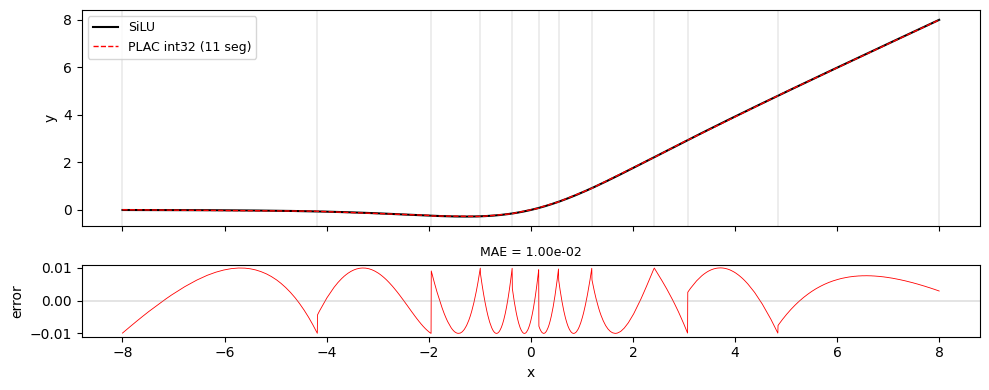

In [4]:
def plot_plac(plac, f, name):
    x = np.linspace(plac.breakpoints_f[0], plac.breakpoints_f[-1], 4000)
    y_true = f(torch.tensor(x, dtype=torch.float64)).numpy()
    y_approx = plac(x)

    _fig, axes = plt.subplots(
        2, 1, figsize=(10, 4), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    axes[0].plot(x, y_true, "k-", lw=1.5, label=name)
    axes[0].plot(x, y_approx, "r--", lw=1, label=f"PLAC int32 ({plac.n_segments} seg)")
    for b in plac.breakpoints_f:
        axes[0].axvline(b, color="gray", lw=0.2)
    axes[0].legend(fontsize=9)
    axes[0].set_ylabel("y")

    axes[1].plot(x, y_true - y_approx, "r-", lw=0.6)
    axes[1].axhline(0, color="gray", lw=0.3)
    axes[1].set_ylabel("error")
    axes[1].set_xlabel("x")
    axes[1].set_title(f"MAE = {plac.max_error(f):.2e}", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_plac(silu_plac, silu, "SiLU")

## GELU approximation

$\text{GELU}(x) = x \cdot \Phi(x)$. Used in GPT-2, BERT, etc.

GELU: 9 segments, MAE = 1.0024e-02


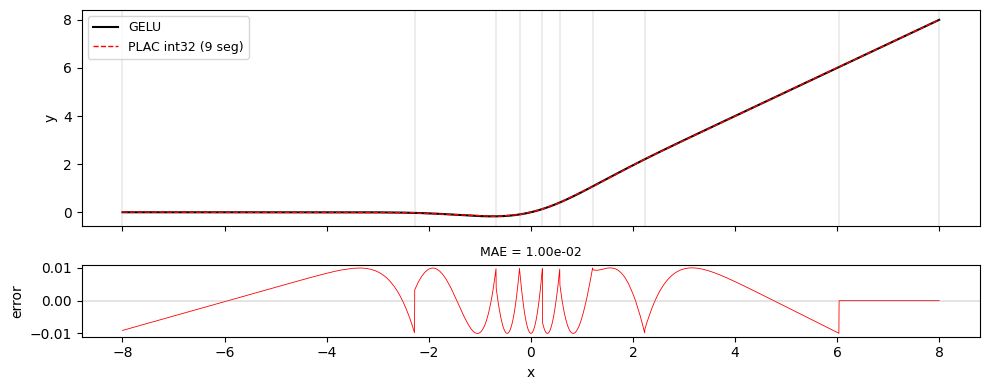

In [5]:
gelu_plac = PLACFunc(gelu, -8, 8, target_mae=1e-2, n_terms=2)
print(f"GELU: {gelu_plac.n_segments} segments, MAE = {gelu_plac.max_error(gelu):.4e}")
plot_plac(gelu_plac, gelu, "GELU")

## Integer evaluation

Internally uses Q16.16 fixed-point. Each segment evaluates as:
```
y = sign0 * (x shift exp0) + sign1 * (x shift exp1) + intercept
```
2 bit-shifts + 2 adds per element. No float multiplies, no memory lookups.

AVX2 kernel: `cmpgt`+`blendv` for segment lookup, `i32gather` for coefficients,
`srav`/`sllv` for variable shifts, `sign_epi32` for sign application. 8 elements/cycle.

In [6]:
x = np.linspace(-8, 8, 10000)

for name, plac, f in [("SiLU", silu_plac, silu), ("GELU", gelu_plac, gelu)]:
    y_true = f(torch.tensor(x, dtype=torch.float64)).numpy()
    y_approx = plac(x)
    print(f"{name}:")
    print(f"  max error: {np.max(np.abs(y_true - y_approx)):.4e}")
    print()

SiLU:
  max error: 1.0019e-02

GELU:
  max error: 1.0024e-02



## Accuracy vs segments tradeoff

In [7]:
targets = [0.05, 0.01, 0.005, 0.001]

header = f"{'target':>8s}  {'SiLU seg':>8s}  {'SiLU MAE':>10s}  {'GELU seg':>8s}  {'GELU MAE':>10s}"
print(header)
for t in targets:
    sp = PLACFunc(silu, -8, 8, target_mae=t)
    gp = PLACFunc(gelu, -8, 8, target_mae=t)
    print(
        f"  {t:>6.4f}  {sp.n_segments:>8d}  {sp.max_error(silu):>10.4e}"
        f"  {gp.n_segments:>8d}  {gp.max_error(gelu):>10.4e}"
    )

  target  SiLU seg    SiLU MAE  GELU seg    GELU MAE
  0.0500         5  5.0011e-02         5  5.0018e-02
  0.0100        11  1.0019e-02         9  1.0024e-02
  0.0050        18  5.0186e-03        12  5.0194e-03
  0.0010        59  1.0254e-03        31  1.0190e-03
